_Part 2: Sections 5-8_

# 6e. Implementing Different Layers

Introducing more types of layers. Showcasing how to implement these layers on first 1D data and then 2D data.

Different use cases for each layer:
* __Convolutional & Fully Connected layers__: Create features
* __Maxpool layers__: Reduce the number of features
* __Non-linear layers__: Introduced as activation functions

Generally most models have a combination of all of the above layers

## 1D Data

In [1]:
# Looking at 1D data
import tensorflow as tf
import numpy as np

# Create input and initialize parameters
DATA_SIZE = 25
CONV_SIZE = 5
MAXPOOL_SIZE = 5
STRIDE_SIZE = 1
NUM_OUTPUTS = 5

x_input_1d = tf.keras.Input(dtype=tf.float32, shape=(DATA_SIZE, 1), name='input_layer')

# Define Convolutional layer
conv_output = tf.keras.layers.Conv1D(
	kernel_size=(CONV_SIZE),
	filters=DATA_SIZE,
	strides=STRIDE_SIZE,
	padding='valid',
	name='convolutional_layer'
)(x_input_1d)

# Add non-linear layer (ReLU)
activation_output = tf.keras.layers.ReLU(name="activation_layer")(conv_output)

# Add maxpool layer - will have 4 fewer entries because of no additional padding
maxpool_output = tf.keras.layers.MaxPool1D(
    pool_size=MAXPOOL_SIZE,
	strides=STRIDE_SIZE,
	padding='valid',
	name='maxpool_layer'
)(activation_output)

# Add fully connected layer - dense layer
full_output = tf.keras.layers.Dense(
	units=NUM_OUTPUTS,
	name='fully_connected_layer'
)(maxpool_output)

In [3]:
# Create the model and print output of each layer
print(">>>> 1D Data <<<<")

model_1D = tf.keras.Model(inputs=x_input_1d, outputs=full_output, name='model_1d')
model_1D.summary()

# Input
print('\n== input_layer ==')
print('Input = array of length %d' % (x_input_1d.shape.as_list()[1]))

# Convolution 
print('\n== convolution_layer ==')
print('Convolution w/ filter, length = %d, stride size = %d, results in an array of length %d' % 
      (CONV_SIZE,STRIDE_SIZE, conv_output.shape.as_list()[1]))

# Activation 
print('\n== activation_layer ==')
print('Input = above array of length %d' % (conv_output.shape.as_list()[1]))
print('ReLU element wise returns an array of length %d' % (activation_output.shape.as_list()[1]))

# Max Pool 
print('\n== maxpool_layer ==')
print('Input = above array of length %d' % (activation_output.shape.as_list()[1]))
print('MaxPool, window length = %d, stride size = %d, results in the array of length %d' %
     (MAXPOOL_SIZE,STRIDE_SIZE,maxpool_output.shape.as_list()[1]))

# Fully Connected 
print('\n== fully_connected_layer ==')
print('Input = above array of length %d' % (maxpool_output.shape.as_list()[1]))
print('Fully connected layer on all 4 rows with %d outputs' % 
      (full_output.shape.as_list()[1]))

>>>> 1D Data <<<<
Model: "model_1d"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_layer (InputLayer)     [(None, 25, 1)]           0         
_________________________________________________________________
convolutional_layer (Conv1D) (None, 21, 25)            150       
_________________________________________________________________
activation_layer (ReLU)      (None, 21, 25)            0         
_________________________________________________________________
maxpool_layer (MaxPooling1D) (None, 17, 25)            0         
_________________________________________________________________
fully_connected_layer (Dense (None, 17, 5)             130       
Total params: 280
Trainable params: 280
Non-trainable params: 0
_________________________________________________________________

== input_layer ==
Input = array of length 25

== convolution_layer ==
Convolution w/ filter, length = 5, st

__*Note: 1D data is important to consider for some neural networks. Some common 1D data include time series, signal processing and some text embeddings, frequently used in neural networks__

## 2D Data

In [4]:
# Define hyperparameters
ROW_SIZE = 10
COL_SIZE = 10
CONV_SIZE = 2
CONV_STRIDE_SIZE = 2
MAXPOOL_SIZE = 2
MAXPOOL_STRIDE_SIZE = 1
NUM_OUTPUTS = 5

# input data
x_input_2d = tf.keras.Input(dtype=tf.float32, shape=(ROW_SIZE, COL_SIZE, 1), name="input_layer_2d")

# Convolutional layer
convolutional_output_2d = tf.keras.layers.Conv2D(
	kernel_size=(CONV_SIZE),
	filters=CONV_SIZE,
	strides=CONV_STRIDE_SIZE,
	padding='valid',
	name='convolutional_layer_2d'
)(x_input_2d)

# Non-linear layer
activation_output_2d = tf.keras.layers.ReLU(name='activation_layer_2d')(convolutional_output_2d)

# Maxpool layer
maxpool_output_2d = tf.keras.layers.MaxPool2D(
	strides=MAXPOOL_STRIDE_SIZE,
	pool_size=MAXPOOL_SIZE,
	padding='valid',
	name='maxpool_layer_2d'
)(activation_output_2d)

# Fully connected layer
full_output_2d = tf.keras.layers.Dense(units=NUM_OUTPUTS, name='fully_connected_layer_2d')(maxpool_output_2d)

In [5]:

print('>>>> 2D Data <<<<')

model_2D = tf.keras.Model(inputs=x_input_2d, outputs=full_output_2d, name="model_2D")
model_2D.summary()

# Input 
print('\n== input_layer ==')
print('Input = %s array' % (x_input_2d.shape.as_list()[1:3]))

# Convolution
print('\n== convolution_layer ==')
print('%s Convolution, stride size = [%d, %d] , results in the %s array' % 
      ([CONV_SIZE,CONV_SIZE],CONV_STRIDE_SIZE,CONV_STRIDE_SIZE,convolutional_output_2d.shape.as_list()[1:3]))

# Activation
print('\n== activation_layer ==')
print('Input = the above %s array' % (convolutional_output_2d.shape.as_list()[1:3]))
print('ReLU element wise returns the %s array' % (activation_output_2d.shape.as_list()[1:3]))

# Max Pool
print('\n== maxpool_layer ==')
print('Input = the above %s array' % (activation_output_2d.shape.as_list()[1:3]))
print('MaxPool, stride size = [%d, %d], results in %s array' % 
      (MAXPOOL_STRIDE_SIZE,MAXPOOL_STRIDE_SIZE,maxpool_output_2d.shape.as_list()[1:3]))

# Fully Connected
print('\n== fully_connected_layer ==')
print('Input = the above %s array' % (maxpool_output_2d.shape.as_list()[1:3]))
print('Fully connected layer on all %d rows results in %s outputs' % 
      (maxpool_output_2d.shape.as_list()[1],full_output_2d.shape.as_list()[3]))

>>>> 2D Data <<<<
Model: "model_2D"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_layer_2d (InputLayer)  [(None, 10, 10, 1)]       0         
_________________________________________________________________
convolutional_layer_2d (Conv (None, 5, 5, 2)           10        
_________________________________________________________________
activation_layer_2d (ReLU)   (None, 5, 5, 2)           0         
_________________________________________________________________
maxpool_layer_2d (MaxPooling (None, 4, 4, 2)           0         
_________________________________________________________________
fully_connected_layer_2d (De (None, 4, 4, 5)           15        
Total params: 25
Trainable params: 25
Non-trainable params: 0
_________________________________________________________________

== input_layer ==
Input = [10, 10] array

== convolution_layer ==
[2, 2] Convolution, stride size = [2, 2] , 

__Summary__

Learned how to use the convolutional and maxpool layers in Tensorflow with both 1D and 2D data. Regardless of the input, outputs of the same size were obtainable, showcasing the flexibility of the NN layers. 

Take note of the importance of shapes and sizes in NN operations. Outputs of each layer, needs to match the input of the subsequent layer.

# 6f. Multilayer Neural Network

Implement a multilayer neural network on low birth weight dataset.

Aim to predict birth weights in the `low birth weight` dataset. Target is the actual birth weight and see what the accuracy of the classification (<2500 grams) at the end 

In [14]:
import tensorflow as tf
import matplotlib.pyplot as plt
import csv
import random
import numpy as np
import requests
import os

# Load data from website using requests module
birth_weight_file = "birth_weight.csv"

if not os.path.exists(birth_weight_file):
    birthdata_url = 'https://github.com/nfmcclure/tensorflow_cookbook/raw/master/01_Introduction/07_Working_with_Data_Sources/birthweight_data/birthweight.dat'
    birth_file = requests.get(birthdata_url)
    birth_data = birth_file.text.split('\r\n')
    birth_header = birth_data[0].split('\t')
    birth_data = [[float(x) for x in y.split('\t') if len(x)>=1] for y in birth_data[1:] if len(y)>=1]
    
    with open(birth_weight_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerows([birth_header])
        writer.writerows(birth_data)
        f.close()

birth_data = []
with open(f"D:/Courses/Machine-Learning-Using-TensorFlow-Cookbook-master/ch6/{birth_weight_file}", newline='') as csvfile:
    csv_reader = csv.reader(csvfile)
    birth_header = next(csv_reader)
    for row in csv_reader:
        birth_data.append(row)

birth_data = [[float(x) for x in row] for row in birth_data]

# Extract y-target (birth weight)
y_vals = np.array([x[8] for x in birth_data])

# Filter for features of interest
cols_of_interest = ['AGE', 'LWT', 'RACE', 'SMOKE', 'PTL', 'HT', 'UI']
x_vals = np.array([[x[ix] for ix, feature in enumerate(birth_header) if feature in cols_of_interest] for x in birth_data])

In [15]:
# Set random seed and hyperparameters
seed = 3
np.random.seed(seed)
tf.random.set_seed(seed)

BATCH_SIZE = 150

# Split data into 80-20 split
train_indices = np.random.choice(len(x_vals), round(len(x_vals) * 0.8))
test_indices = np.array(list(set(range(len(x_vals))) - set(train_indices)))
x_train = x_vals[train_indices]
y_train = y_vals[train_indices]
x_test = x_vals[test_indices]
y_test = y_vals[test_indices]

## record training column max and min for scaling of non-training data
train_max = np.max(x_train, axis=0)
train_min = np.min(x_train, axis=0)

## normalize by column (min-max norm to be between 0 and 1)
def normalize_cols(mat, max_vals, min_vals):
    return (mat - min_vals) / (max_vals - min_vals)

train_x_norm = np.nan_to_num(normalize_cols(x_train, train_max, train_min)) 
test_x_norm = np.nan_to_num(normalize_cols(x_test, train_max, train_min)) 

In [16]:
# Functions to initilize the weights, bias and fc layer
def init_weight(shape, st_dev):
    weight = tf.Variable(tf.random.normal(shape, stddev=st_dev))
    return weight

def init_bias(shape, st_dev):
    bias = tf.Variable(tf.random.normal(shape, stddev=st_dev))
    return bias

def fc_layer(input_layer, weights, biases):
    return tf.keras.layers.Lambda(lambda x: tf.nn.relu(tf.add(tf.matmul(x, weights), biases)))(input_layer)

# Initialize input data
x_data = tf.keras.Input(dtype=tf.float32, shape=(7, ))

# Create model
## ---- First Layer (25 hidden nodes) ----
weights_1 = init_weight(shape=[7, 25], st_dev=5.0)
bias_1 = init_bias(shape=[25], st_dev=10.0)
layer_1 = fc_layer(x_data, weights_1, bias_1)

## ---- Second Layer (10 hidden nodes) ----
weights_2 = init_weight(shape=[25, 10], st_dev=5.0)
bias_2 = init_bias(shape=[10], st_dev=10.0)
layer_2 = fc_layer(layer_1, weights_2, bias_2)

## ---- Third Layer (3 hidden nodes) ----
weights_3 = init_weight(shape=[10, 3], st_dev=5.0)
bias_3 = init_bias(shape=[3], st_dev=10.0)
layer_3 = fc_layer(layer_2, weights_3, bias_3)

## ---- Output Layer (1 output value) ----
weights_4 = init_weight(shape=[3, 1], st_dev=5.0)
bias_4 = init_bias(shape=[1], st_dev=10.0)
final_output = fc_layer(layer_3, weights_4, bias_4)
model = tf.keras.Model(inputs=x_data, outputs=final_output, name='multi-layer_neural_network')

The following Variables were used a Lambda layer's call (lambda_14), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=(7, 25) dtype=float32>
  <tf.Variable 'Variable:0' shape=(25,) dtype=float32>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.
The following Variables were used a Lambda layer's call (lambda_15), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=(25, 10) dtype=float32>
  <tf.Variable 'Variable:0' shape=(10,) dtype=float32>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.
The following Variables were used a Lambda layer's call (lambda_16), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=(10, 3) 

In [19]:
# Declare Adam optimizer
optimizer = tf.keras.optimizers.Adam(0.025)

# Training Loop
loss_vec = []
test_loss = []
for i in range(200):
  rand_index = np.random.choice(len(train_x_norm), size=BATCH_SIZE)
  rand_x = train_x_norm[rand_index]
  rand_y = np.transpose([y_train[rand_index]])
  
  with tf.GradientTape(persistent=True) as tape:
    output = model(rand_x)
    loss = tf.reduce_mean(tf.abs(rand_y - output))
    loss_vec.append(loss)
  
  gradient_w1 = tape.gradient(loss, weights_1)
  gradient_b1 = tape.gradient(loss, bias_1)
  gradient_w2 = tape.gradient(loss, weights_2)
  gradient_b2 = tape.gradient(loss, bias_2)
  gradient_w3 = tape.gradient(loss, weights_3)
  gradient_b3 = tape.gradient(loss, bias_3)
  gradient_w4 = tape.gradient(loss, weights_4)
  gradient_b4 = tape.gradient(loss, bias_4)
  
  optimizer.apply_gradients(zip([gradient_w1, gradient_b1, gradient_w2, gradient_b2, gradient_w3, gradient_b3, gradient_w4, gradient_b4], [weights_1, bias_1, weights_2, bias_2, weights_3, bias_3, weights_4, bias_4]))

  output_test = model(test_x_norm)
  
  temp_loss = tf.reduce_mean(tf.abs(np.transpose([y_test]) - output_test))
  test_loss.append(temp_loss)
  
  if (i+1) % 25 == 0:
    print(f"Generation: {str(i+1)} | Loss = {str(loss.numpy())}")

Generation: 25 | Loss = 1812.5436
Generation: 50 | Loss = 1271.522
Generation: 75 | Loss = 851.8707
Generation: 100 | Loss = 601.4322
Generation: 125 | Loss = 553.7792
Generation: 150 | Loss = 451.83817
Generation: 175 | Loss = 441.51907
Generation: 200 | Loss = 354.5059


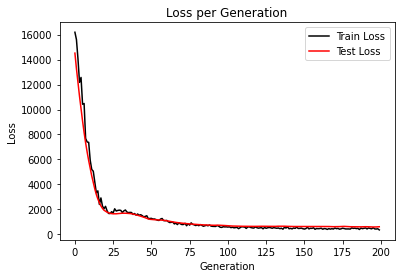

In [20]:
# Plotting train and test loss
plt.plot(loss_vec, 'k-', label='Train Loss')
plt.plot(test_loss, 'r-', label='Test Loss')
plt.title('Loss per Generation')
plt.xlabel('Generation')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [23]:
# Output train and test regression results -> change to classification results
#		if >2,500g then 0 else 1
actuals = np.array([x[0] for x in birth_data])
test_actuals = actuals[test_indices]
train_actuals = actuals[train_indices]
test_preds = model(test_x_norm)
train_preds = model(train_x_norm)
test_results = np.array([1.0 if x<2500 else 0.0 for x in test_preds])
train_results = np.array([1.0 if x<2500 else 0.0 for x in train_preds])

# Print accuracies
test_acc = np.mean([x == y for x, y in zip(test_results, test_actuals)])
train_acc = np.mean([x == y for x, y in zip(train_results, train_actuals)])
print("On prediciting the category of low birthweights from regression output (<2500g)")
print(f"Test Accuracy: {test_acc}")
print(f"Train Accuracy: {train_acc}")

On prediciting the category of low birthweights from regression output (<2500g)
Test Accuracy: 0.7444444444444445
Train Accuracy: 0.7748344370860927


__Summary__

Created a regression neural netowrk with 3 fully connected hidden layers to predict the birth weight of low birth weight dataset.

Achieve relatively good training and testing accuracy

# 6g. Improving Prediction of Linear Models

Instead of applying a threshold value to the outputs of a regression model, we will use a sigmoid function applied to a neural network to make the model non-linear and train against the categorized values from the start. This should increase the accuracy of the low birth weight prediction.

Use the low birth weight data and use a neural netowrk with 2 hidden fully connected layers with sigmoid activations

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import requests
import os
import csv

In [31]:
tf.keras.backend.set_floatx("float64")
# Similar to above, load and normalize dataset, but target variable will be the indicator variable of actual birth weight
birth_weight_file = "birth_weight.csv"

if not os.path.exists(birth_weight_file):
    birthdata_url = 'https://github.com/nfmcclure/tensorflow_cookbook/raw/master/01_Introduction/07_Working_with_Data_Sources/birthweight_data/birthweight.dat'
    birth_file = requests.get(birthdata_url)
    birth_data = birth_file.text.split('\r\n')
    birth_header = birth_data[0].split('\t')
    birth_data = [[float(x) for x in y.split('\t') if len(x)>=1] for y in birth_data[1:] if len(y)>=1]
    
    with open(birth_weight_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerows([birth_header])
        writer.writerows(birth_data)
        f.close()

birth_data = []
with open(f"D:/Courses/Machine-Learning-Using-TensorFlow-Cookbook-master/ch6/{birth_weight_file}", newline='') as csvfile:
    csv_reader = csv.reader(csvfile)
    birth_header = next(csv_reader)
    for row in csv_reader:
        birth_data.append(row)

birth_data = [[float(x) for x in row] for row in birth_data]

# Pull out target vairable
y_vals = np.array([x[0] for x in birth_data])
# Pull out predictor variables (not id, not target, not birthweight)
x_vals = np.array([x[1:8] for x in birth_data])

train_indices = np.random.choice(len(x_vals), round(len(x_vals) * 0.8))
test_indices = np.array(list(set(range(len(x_vals))) - set(train_indices)))

x_train = x_vals[train_indices]
y_train = y_vals[train_indices]
x_test = x_vals[train_indices]
y_test = y_vals[test_indices]

def normalize_cols(m):
    col_max = m.max(axis=0)
    col_min = m.min(axis=0)
    return (m-col_min) / (col_max - col_min)

x_train_norm = np.nan_to_num(normalize_cols(x_train))
x_test_norm = np.nan_to_num(normalize_cols(x_test))

In [32]:
BATCH_SIZE = 90
seed = 98
np.random.seed(seed)
tf.random.set_seed(seed)
x_data = tf.keras.Input(dtype=tf.float64, shape=(7, ))

In [34]:
# Create variable definition
def init_variable(shape):
  return (tf.Variable(tf.random.normal(shape=shape, dtype="float64", seed=seed)))

# Create a logistic layer definition
def logistic(input_layer, multiplication_weight, bias_weight, activation=True):
	if activation:
		return tf.keras.layers.Lambda(lambda x: tf.nn.sigmoid(tf.add(tf.matmul(x, multiplication_weight), bias_weight)))(input_layer)
	else:
		return tf.keras.layers.Lambda(lambda x: tf.add(tf.matmul(x, multiplication_weight), bias_weight))(input_layer)

# Declare 3 layers
# ---- First Logistic Layer (7 inputs to 14 hidden nodes) ----
A1 = init_variable(shape=[7, 14])
b1 = init_variable(shape=[14])
logistic_layer_1 = logistic(x_data, A1, b1)
# ---- Second Logistic Layer (14 hidden inputs to 5 hidden nodes) ----
A2 = init_variable(shape=[14, 5])
b2 = init_variable(shape=[5])
logistic_layer_2 = logistic(logistic_layer_1, A2, b2)
# --- Final Ouput Layer (5 hidden nodes to 1 output) ----
A3 = init_variable(shape=[5, 1])
b3 = init_variable(shape=[1])
final_output = logistic(logistic_layer_2, A3, b3, activation=False)
# Build Model
model = tf.keras.Model(inputs=x_data, outputs=final_output, name="multi-layer_logistic_neural_network")

The following Variables were used a Lambda layer's call (lambda_21), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=(7, 14) dtype=float64>
  <tf.Variable 'Variable:0' shape=(14,) dtype=float64>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.
The following Variables were used a Lambda layer's call (lambda_22), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=(14, 5) dtype=float64>
  <tf.Variable 'Variable:0' shape=(5,) dtype=float64>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.
The following Variables were used a Lambda layer's call (lambda_23), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=(5, 1) dty

In [38]:
# Define Loss Function (Binary Cross Entropy)
def cross_entropy(final_output, y_target):
  return tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=final_output, labels=y_target))

# Define Optimizer
optimizer = tf.keras.optimizers.Adam(0.002)

# Accuracy
def compute_accuracy(final_output, y_target):
  prediction = tf.round(tf.nn.sigmoid(final_output))
  predictions_correct = tf.cast(tf.equal(prediction, y_target), tf.float32)
  return tf.reduce_mean(predictions_correct)

# Training Loop
loss_vec = []
train_acc = []
test_acc = []
for i in range(1500):
  rand_index = np.random.choice(len(x_train_norm), size=BATCH_SIZE)
  rand_x = x_train_norm[rand_index]
  rand_y = np.transpose([y_train[rand_index]])
  
  # Open a GradientTape
  with tf.GradientTape(persistent=True) as tape:
    output = model(rand_x)
    
    loss = cross_entropy(output, rand_y)
    loss_vec.append(loss)
    
  # Get gradients of loss with reference to the weights
  gradients_A1 = tape.gradient(loss, A1)
  gradients_b1 = tape.gradient(loss, b1)
  gradients_A2 = tape.gradient(loss, A2)
  gradients_b2 = tape.gradient(loss, b2)
  gradients_A3 = tape.gradient(loss, A3)
  gradients_b3 = tape.gradient(loss, b3)
  
  # Update the weights and bias variables of the model
  optimizer.apply_gradients(zip([gradients_A1, gradients_b1, gradients_A2, gradients_b2, gradients_A3, gradients_b3], [A1, b1, A2, b2, A3, b3]))
  
  temp_acc_train = compute_accuracy(model(x_train_norm), y_train)
  train_acc.append(temp_acc_train)
  
  temp_acc_test = compute_accuracy(model(x_test_norm), y_test)
  test_acc.append(temp_acc_test)
  
  if (i+1) % 150 == 0:
    print(f"Loss = {loss.numpy()}")

Loss = 0.806782199514455
Loss = 0.6530346211828255
Loss = 0.591876095028439
Loss = 0.5735867814006913
Loss = 0.4874196769064544
Loss = 0.5173369843301923
Loss = 0.5023958606090281
Loss = 0.5331104084496281
Loss = 0.3731055350073898
Loss = 0.3599846316717219


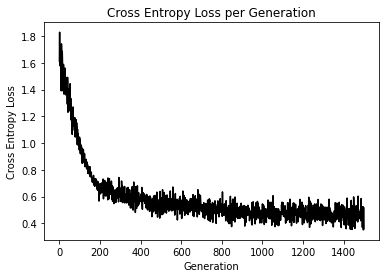

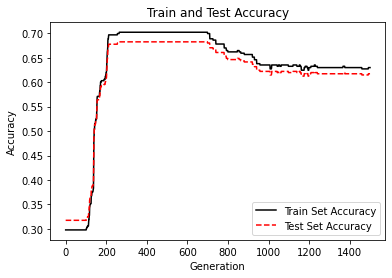

In [39]:
%matplotlib inline
# Plot loss over time
plt.plot(loss_vec, 'k-')
plt.title('Cross Entropy Loss per Generation')
plt.xlabel('Generation')
plt.ylabel('Cross Entropy Loss')
plt.show()

# Plot train and test accuracy
plt.plot(train_acc, 'k-', label='Train Set Accuracy')
plt.plot(test_acc, 'r--', label='Test Set Accuracy')
plt.title('Train and Test Accuracy')
plt.xlabel('Generation')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

__Summary__

This model coverges faster and has a higher accuracy compared to the previous model. But when using neural networks, consider the advantages and disadvantages of each model. 

This model has a higher accuracy, but uses more variables which has a higher chance of overfitting. If the accuracy of the training set continues to increase, but the accuracy of the testing set decreases or stays relatively the same, means the model might have been overfitted already. Adding more data or regularization techniques will help to prevent overfitting

For underfitting, increasing the model depth (increase the number of layers) or training on more iterations might help to increase accuracy. 

Using more complex models also reduces the interpretability of the final coefficients. The model above has 200+ coefficients which is harder to explain what each one does compared to a liner model.

# 6h. Learning to play Tic-Tac-Toe

Use a neural network to learn the optimal moves for Tic-Tac-Toe, taking the game to be deterministic.

Use a list of board positions followed by the corresponding optimal reponse to train. Reduce the number of data points to train by removing board instances that are symmetrical on non-identity transformations (e.g 90deg, 180deg, horizontal reflections, ...)

__Data__

A datapoint would look like this:

`[-1, 0, 0, 1, -1, -1, 0, 0, 1]` where 1 will represent an X and -1 will represent O. Left to right, will represent the board going top to bottom, left to right in order

Shortlist board poitions, apply random transformations and feed into neural network for training.

__Training Evaluation__

1. Remove a position and an optimal move row from training set
2. Play against the model till the end

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import csv
import random

<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 80 from C header, got 96 from PyObject
<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 216 from C header, got 232 from PyObject
<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 216 from C header, got 232 from PyObject
<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 216 from C header, got 232 from PyObject


In [3]:
# Declare batch size
BATCH_SIZE = 50

# Visualization of the board
def print_board(board):
  '''
	Takes in a board layout and visualizes it
  '''
  symbols = ['O', ' ', 'X']
  board_plus1 = [int(x)  + 1 for x in board]
  final_board = ""
  divider = "\n______________\n" 
  base = 0
  for i in range(3):
    row = f"{symbols[board_plus1[base]]} | {symbols[board_plus1[base+1]]} | {symbols[board_plus1[base+2]]}"
    final_board += row
    if i != 2:
      final_board += divider
    base += 3
  return final_board

print(print_board([-1, 0, 0, 1, -1, -1, 0, 0, 1]))


O |   |  
______________
X | O | O
______________
  |   | X


In [4]:
# Return a new board and an optimal response position under transformation
# 	This will help to expose the model to similar scenarios and their corresponding optimal outcomes
#		without the need for more data points
def get_symmetry(board, response, transformation):
  '''
  :param board (list): list of integers 9 long
  :param response (int): integer of the best response
  :param transformation (string): rotate180, rotate90, rotate270, flip_v, flip_h
  ::return (tuple):: (new_board, new_response)
  '''
  if transformation == 'rotate180':
        new_response = 8 - response
        return board[::-1], new_response
  elif transformation == 'rotate90':
      new_response = [6, 3, 0, 7, 4, 1, 8, 5, 2].index(response)
      tuple_board = list(zip(*[board[6:9], board[3:6], board[0:3]]))
      return [value for item in tuple_board for value in item], new_response
  elif transformation == 'rotate270':
      new_response = [2, 5, 8, 1, 4, 7, 0, 3, 6].index(response)
      tuple_board = list(zip(*[board[0:3], board[3:6], board[6:9]]))[::-1]
      return [value for item in tuple_board for value in item], new_response
  elif transformation == 'flip_v':
      new_response = [6, 7, 8, 3, 4, 5, 0, 1, 2].index(response)
      return board[6:9] + board[3:6] + board[0:3], new_response
  elif transformation == 'flip_h':  # flip_h = rotate180, then flip_v
      new_response = [2, 1, 0, 5, 4, 3, 8, 7, 6].index(response)
      new_board = board[::-1]
      return new_board[6:9] + new_board[3:6] + new_board[0:3], new_response
  else:
      raise ValueError('Method not implemented.')

In [5]:
# Get list of boards and optimal responses in a .csv file 
#		create a function that will load the file with boards and response
#		store it as a list of tuples
def get_moves_from_csv(csv_file):
  '''
	:param csv_file (string): csv file location containing the board moves
	::return moves (list):: list of moves with index of best response
  '''
  play_moves = []
  with open(csv_file, 'rt') as csvfile:
      reader = csv.reader(csvfile, delimiter=',')
      for row in reader:
          play_moves.append(([int(x) for x in row[0:9]], int(row[9])))
  return play_moves

In [6]:
# Function that will return a randomly transformed board and response
def get_rand_move(moves, rand_transforms=2):
  '''
	:param moves (list): list of moves and their responses
	:param rand_transforms (int): how many random transformations were performed
	:return response (list): board - list of 9 integers and response - single integer
  '''
  (board, play_response) = random.choice(moves)
  possible_transforms = ['rotate90', 'rotate180', 'rotate270', 'flip_v', 'flip_h']
  for _ in range(rand_transforms):
      random_transform = random.choice(possible_transforms)
      (board, play_response) = get_symmetry(board, play_response, random_transform)
  return board, play_response

In [14]:
# Load data and create a training set
moves = get_moves_from_csv('base_tic_tac_toe_moves.csv')
train_length = 500
train_set = []
for t in range(train_length):
  train_set.append(get_rand_move(moves))

# Select 1 instance as the test case
# 	- remove all instances of this test case from the training set
#		- ensures that the model is generalized to predict on unseen cases before
test_board = [-1, 0, 0, 1, -1, -1, 0, 0, 1]
train_set = [x for x in train_set if x[0] != test_board]

# Initialize weights and bias to create model
def init_weights(shape):
  return tf.Variable(tf.random.normal(shape))
A1 = init_weights([9, 81])
bias1 = init_weights([81])
A2 = init_weights([81, 9])
bias2 = init_weights([9])

# Create the model
X = tf.keras.Input(dtype=tf.float32, batch_input_shape=[None, 9])
hidden_output = tf.keras.layers.Lambda(lambda x: tf.nn.sigmoid(tf.add(tf.matmul(x, A1), bias1)))(X)
final_output = tf.keras.layers.Lambda(lambda x: tf.nn.sigmoid(tf.add(tf.matmul(x, A2), bias2)))(hidden_output)
model = tf.keras.Model(inputs=X, outputs=final_output, name="ttc_neural_net")

# Define model parameters
optimizer = tf.keras.optimizers.SGD(0.025)

The following Variables were used a Lambda layer's call (lambda_4), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=(9, 81) dtype=float32>
  <tf.Variable 'Variable:0' shape=(81,) dtype=float32>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.
The following Variables were used a Lambda layer's call (lambda_5), but
are not present in its tracked objects:
  <tf.Variable 'Variable:0' shape=(81, 9) dtype=float32>
  <tf.Variable 'Variable:0' shape=(9,) dtype=float32>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.


In [15]:
# Actual training loop
loss_vec = []
batch_size = 50
for i in range(10000):
  rand_indices = np.random.choice(range(len(train_set)), batch_size, replace=False)
  batch_data = [train_set[i] for i in rand_indices]
  x_input = [x[0] for x in batch_data]
  y_target = np.array([y[1] for y in batch_data])
  
  with tf.GradientTape(persistent=True) as tape:
    output = model(np.array(x_input, dtype=float))
    loss = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(logits=output, labels=y_target))
    loss_vec.append(loss)
  
  gradients_A1 = tape.gradient(loss, A1)
  gradients_bias1 = tape.gradient(loss, bias1)
  gradients_A2 = tape.gradient(loss, A2)
  gradients_bias2 = tape.gradient(loss, bias2)
  
  optimizer.apply_gradients(zip([gradients_A1, gradients_bias1, gradients_A2, gradients_bias2], [A1, bias1, A2, bias2]))
  
  if i % 500 == 0:
    print(f"Iteration {i}, Loss: {loss}")

Iteration 0, Loss: 2.394552230834961
Iteration 500, Loss: 2.338834047317505
Iteration 1000, Loss: 2.2406821250915527
Iteration 1500, Loss: 2.134295701980591
Iteration 2000, Loss: 2.142653703689575
Iteration 2500, Loss: 2.0862483978271484
Iteration 3000, Loss: 2.1077399253845215
Iteration 3500, Loss: 2.0535452365875244
Iteration 4000, Loss: 2.079643964767456
Iteration 4500, Loss: 2.0291168689727783
Iteration 5000, Loss: 2.0298643112182617
Iteration 5500, Loss: 2.03568172454834
Iteration 6000, Loss: 1.9542962312698364
Iteration 6500, Loss: 1.9694223403930664
Iteration 7000, Loss: 1.9636943340301514
Iteration 7500, Loss: 2.0287249088287354
Iteration 8000, Loss: 1.935297966003418
Iteration 8500, Loss: 1.9472180604934692
Iteration 9000, Loss: 1.9833086729049683
Iteration 9500, Loss: 1.9927046298980713


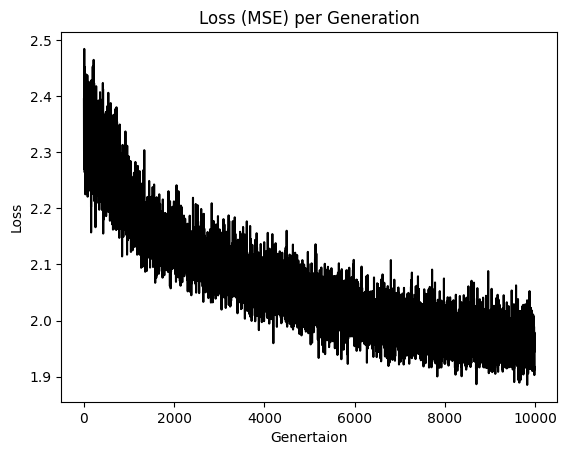

In [16]:
import matplotlib.pyplot as plt

plt.plot(loss_vec, 'k-', label='Loss')
plt.title('Loss (MSE) per Generation')
plt.xlabel('Genertaion')
plt.ylabel('Loss')
plt.show()

In [17]:
# Test model against test board
test_boards = [test_board]
logits = model.predict(test_boards)
predictions = tf.argmax(logits, 1)
print(predictions)

1/1 [==============================] - 0s 145ms/step
tf.Tensor([6], shape=(1,), dtype=int64)


In [24]:
# To evaluate the model, need to play against a live opponent
# 	- function to check for a win
def check(board):
	wins = [[0, 1, 2], [3, 4, 5], [6, 7, 8], [0, 3, 6], [1, 4, 7], [2, 5, 8], [0, 4, 8], [2, 4, 6]]
	for ix in range(len(wins)):
			if board[wins[ix][0]] == board[wins[ix][1]] == board[wins[ix][2]] == 1.:
					return 1
			elif board[wins[ix][0]] == board[wins[ix][1]] == board[wins[ix][2]] == -1.:
					return -1
	return 0

# Play against the board
game_tracker = [0., 0., 0., 0., 0., 0., 0., 0., 0.]
win_logical = False
num_moves = 0

while not win_logical:
  player_index = input('Input index of your move (0-8)')
  num_moves += 1
  
  game_tracker[int(player_index)] = 1.
  
  # get list of potential moves
  [potential_moves] = model(np.array([game_tracker], dtype=float))
  # find the set of allowed moves
  allowed_moves = [ix for ix, x in enumerate(game_tracker) if x == 0.]
	# find the best move	
  model_move = np.argmax([x if ix in allowed_moves else -999.0 for ix, x in enumerate(potential_moves)])
  
  # add model mvoe to the game
  game_tracker[int(model_move)] = -1.
  print('Model has moved')
  print(print_board(game_tracker))
  
  # Check if there is a win or if there are too many moves
  if check(game_tracker) == -1 or num_moves >= 5:
    print('Game Over!')
    win_logical = True
  elif check(game_tracker) == 1:
    print('Congratulations! You won!')
    win_logical = True
  


Model has moved
  |   |  
______________
  | X |  
______________
O |   |  
Model has moved
X |   |  
______________
  | X |  
______________
O |   | O
Model has moved
X |   | X
______________
  | X | O
______________
O |   | O
Model has moved
X | X | X
______________
O | X | O
______________
O |   | O
Congratulations! You won!


Generally it's still quite easy to beat the model. But there is some logic, the model was able to block a potential winning space and will still try to win if the player makes no attempt to win. Much can be done to improve the model, including things like reinforcement learning to continuously learn as the game progresses